In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.interpolate import griddata
from scipy.stats import qmc 
from scipy import stats
import time
import gurobipy as gp
import pandas as pd



In [2]:
results_df = pd.read_csv("cvar_results_lip.csv")
mean_loss_column = results_df['Mean_Loss'].to_numpy()
cvar_column = results_df['CVaR'].to_numpy()
W1=results_df['w1'].to_numpy()
W2=results_df['w2'].to_numpy()
feasible_region=np.column_stack((W1,W2))




In [3]:
CVaR = np.array(cvar_column)
np.shape(CVaR)

(5151,)

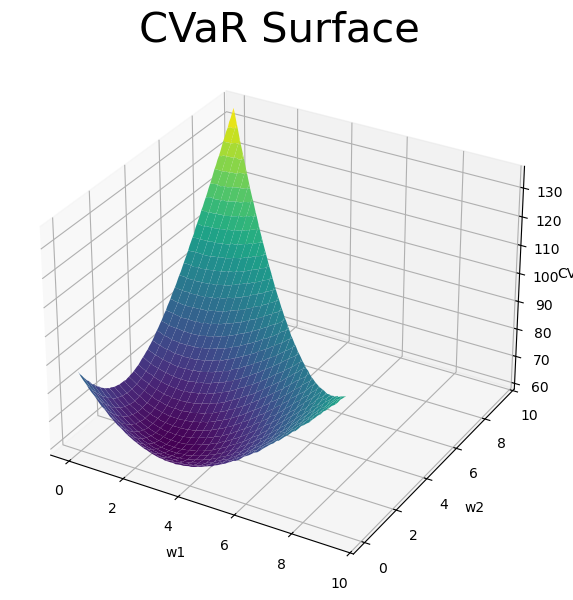

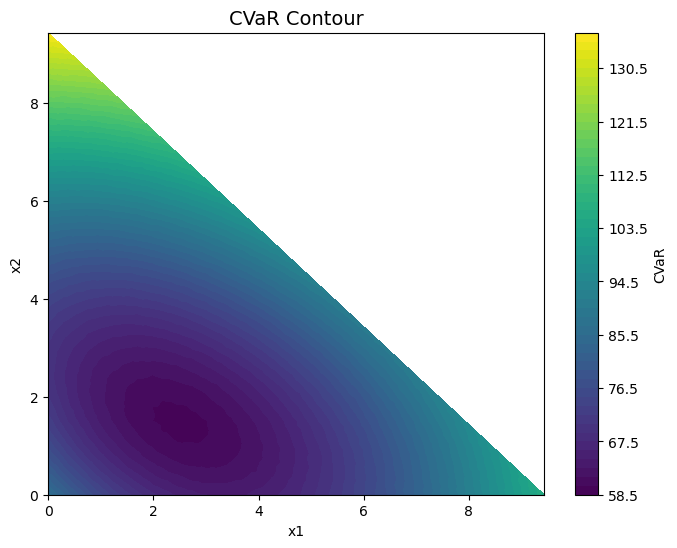

In [4]:
# Convert to numpy array
CVaR = np.array(cvar_column)

# Read the actual w1, w2 data points from the CSV file
W1_data = results_df['w1'].to_numpy()
W2_data = results_df['w2'].to_numpy()
feasible_region = np.column_stack((W1_data, W2_data))

# Create a 2D grid for plotting

W1, W2 = np.meshgrid(W1_data, W2_data)
# Remove duplicate points
W1=np.unique(W1)
W2=np.unique(W2)
W1_grid, W2_grid = np.meshgrid(W1, W2)

# Interpolate onto a regular grid
grid_CVaR = griddata((feasible_region[:, 0], feasible_region[:, 1]), CVaR, (W1_grid, W2_grid), method='cubic')

# Plot the surface of CVaR versus (w1, w2)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1_grid, W2_grid, grid_CVaR, cmap='viridis', edgecolor='none')

# Set the plot title and axis labels
ax.set_title('CVaR Surface', fontsize=30)
ax.set_xlabel('w1')
ax.set_ylabel('w2')
ax.set_zlabel('CVaR')

plt.show()

# Plot the filled contour of CVaR versus (w1, w2)
plt.figure(figsize=(8, 6))
plt.contourf(W1_grid, W2_grid, grid_CVaR, levels=50, cmap='viridis')
plt.colorbar(label='CVaR')

# Set the plot title and axis labels
plt.title('CVaR Contour', fontsize=14)
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

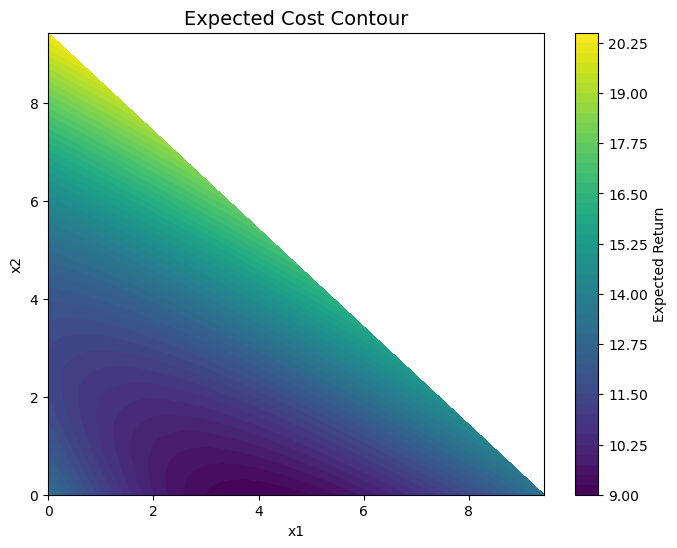

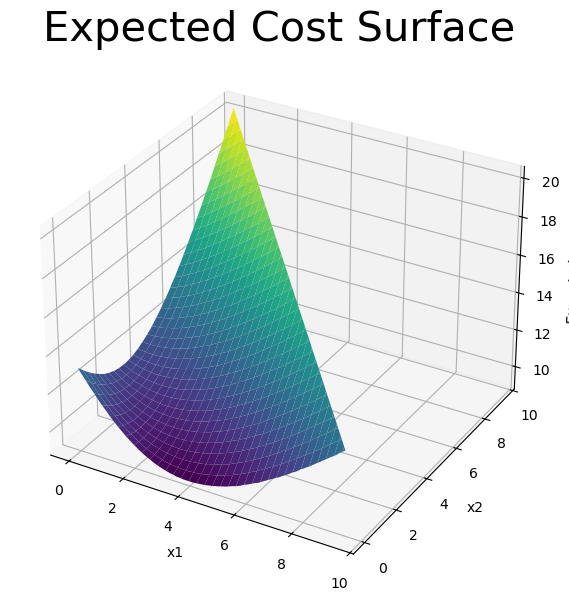

In [5]:
# Convert to numpy array
expected_returns = np.array(mean_loss_column)


# Read the actual w1, w2 data points from the CSV file
W1_data = results_df['w1'].to_numpy()
W2_data = results_df['w2'].to_numpy()
feasible_region = np.column_stack((W1_data, W2_data))

# Create a 2D grid for plotting

W1, W2 = np.meshgrid(W1_data, W2_data)
# Remove duplicate points
W1=np.unique(W1)
W2=np.unique(W2)
W1_grid, W2_grid = np.meshgrid(W1, W2)


# Interpolate onto a regular grid
grid_expected_return = griddata((feasible_region[:, 0], feasible_region[:, 1]), expected_returns, (W1_grid, W2_grid), method='cubic')

# Plot the filled contour of the expected return
plt.figure(figsize=(8, 6))
plt.contourf(W1_grid, W2_grid, grid_expected_return, levels=50, cmap='viridis')
plt.colorbar(label='Expected Return')

# Set the plot title and axis labels
plt.title('Expected Cost Contour', fontsize=14)
plt.xlabel('x1')
plt.ylabel('x2')

plt.show()

# Plot the surface of CVaR versus (w1, w2)
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1_grid, W2_grid, grid_expected_return, cmap='viridis', edgecolor='none')

# Set the plot title and axis labels
ax.set_title('Expected Cost Surface', fontsize=30)
ax.set_xlabel('x1')
ax.set_ylabel('x2')
ax.set_zlabel('Expected Cost')

plt.show()

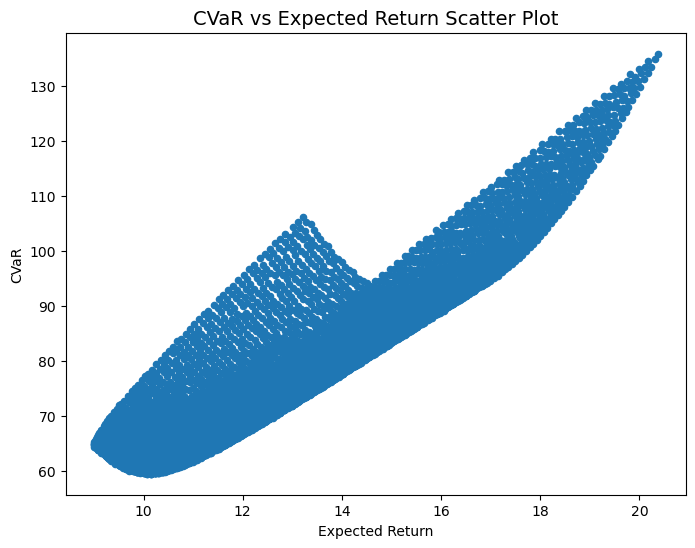

In [6]:
# Plot the scatter of CVaR versus expected return
plt.figure(figsize=(8, 6))
plt.scatter(expected_returns, CVaR, s=20)
#plt.colorbar(label='CVaR')

# Set the plot title and axis labels
plt.title('CVaR vs Expected Return Scatter Plot', fontsize=14)
plt.xlabel('Expected Return')
plt.ylabel('CVaR')

plt.show()

In [7]:
def find_pareto_frontier(input_data):
    """
    Compute the Pareto frontier.
    
    Parameters:
    input_data -- input 2D numpy array where each row is a multi-objective data point
    
    Returns:
    membership -- boolean array indicating whether each point is on the Pareto frontier
    member_value -- the set of Pareto frontier points
    """
    # Initialize the list that stores the Pareto frontier points
    pareto_frontier = []

    # Iterate over each data point
    for i in range(input_data.shape[0]):
        # Current data point
        c_data = np.tile(input_data[i, :], (input_data.shape[0], 1))
        # Copy the input data
        t_data = input_data.copy()
        # Mark the current point as infinity to exclude itself
        t_data[i, :] = np.inf

        # Check whether the current point is greater than or equal to all other points in every dimension
        smaller_idx = c_data >= t_data

        # If the current point is not dominated by any other point, add it to the Pareto frontier
        if not np.any(np.sum(smaller_idx, axis=1) == input_data.shape[1]):
            pareto_frontier.append(input_data[i, :])

    # Convert to numpy array
    pareto_frontier = np.array(pareto_frontier)

    # Generate the membership boolean array indicating whether each point is on the Pareto frontier
    membership = np.array([np.any(np.all(input_data[i] == pareto_frontier, axis=1)) for i in range(input_data.shape[0])])

    return membership, pareto_frontier

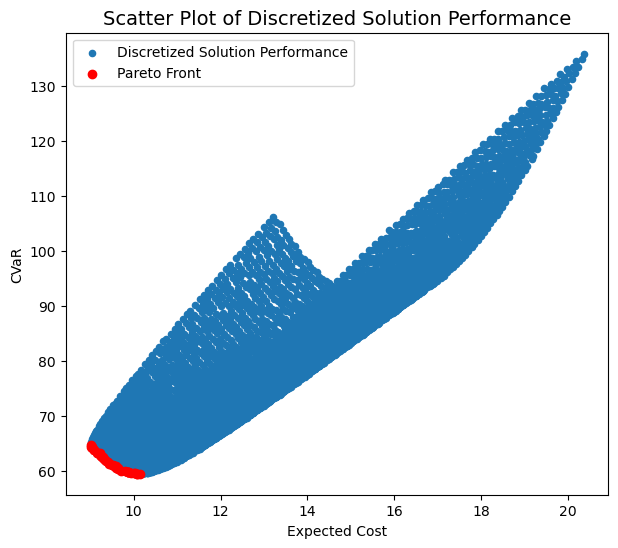

In [8]:
# Find the Pareto frontier
points = np.column_stack((expected_returns, CVaR))  # Combine expected_returns and CVaR into a point set
membership, pareto_frontier = find_pareto_frontier(points)  # Compute the Pareto frontier

# Plot the scatter of CVaR versus expected return
plt.figure(figsize=(7, 6))
plt.scatter(expected_returns, CVaR, s=20, label='Discretized Solution Performance')

# Annotate the Pareto frontier points
plt.scatter(pareto_frontier[:, 0], pareto_frontier[:, 1], color='r', label='Pareto Front', edgecolor='red')

# Set the plot title and axis labels
plt.title('Scatter Plot of Discretized Solution Performance', fontsize=14)
plt.xlabel('Expected Cost')
plt.ylabel('CVaR')
#plt.set_aspect('equal')
# Add the legend
plt.legend()
plt.show()

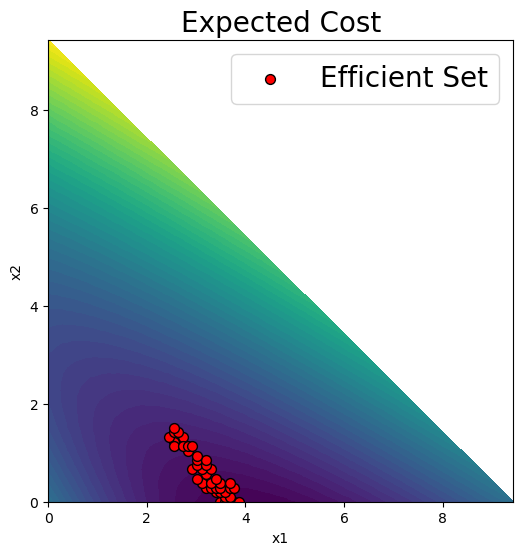

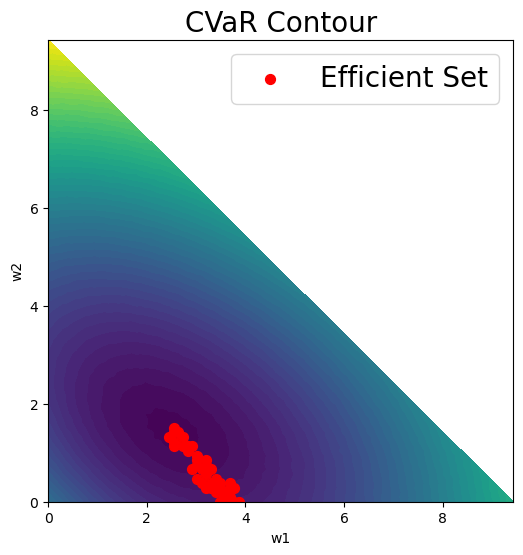

In [9]:
# Create a regular 2D grid for interpolation (if not already created)
# Create the grid based on the value ranges of W1 and W2
w1_min, w1_max = W1.min(), W1.max()
w2_min, w2_max = W2.min(), W2.max()

# Create regular grid points (grid density can be adjusted as needed)
grid_resolution = 101
w1_grid = np.linspace(w1_min, w1_max, grid_resolution)
w2_grid = np.linspace(w2_min, w2_max, grid_resolution)
W1_grid, W2_grid = np.meshgrid(w1_grid, w2_grid)

# Recompute the interpolation, ensuring a 2D grid is used
expected_returns = np.array(mean_loss_column)
grid_expected_return = griddata((feasible_region[:, 0], feasible_region[:, 1]), expected_returns, (W1_grid, W2_grid), method='cubic')

CVaR = np.array(cvar_column)
grid_CVaR = griddata((feasible_region[:, 0], feasible_region[:, 1]), CVaR, (W1_grid, W2_grid), method='cubic')

# Plot the filled contour of the expected return
plt.figure(figsize=(6, 6))
plt.contourf(W1_grid, W2_grid, grid_expected_return, levels=50, cmap='viridis')
#plt.colorbar(label='Expected Return')

# Annotate the solutions corresponding to the Pareto frontier on the contour plot
pareto_feasible_solutions = feasible_region[membership]  # Find the solutions corresponding to the Pareto front based on membership
plt.scatter(pareto_feasible_solutions[:, 0], pareto_feasible_solutions[:, 1], color='r', s=50, label='Efficient Set', edgecolor='black')

# Set the plot title and axis labels
plt.title('Expected Cost', fontsize=20)
plt.xlabel('x1')
plt.ylabel('x2')

# Add the legend
plt.legend(fontsize=20) 
plt.show()


# Plot the filled contour of CVaR versus (w1, w2)
plt.figure(figsize=(6, 6))
plt.contourf(W1_grid, W2_grid, grid_CVaR, levels=50, cmap='viridis')
#plt.colorbar(label='CVaR')
plt.scatter(pareto_feasible_solutions[:, 0], pareto_feasible_solutions[:, 1], color='r', s=50, label='Efficient Set')
# Set the plot title and axis labels
plt.title('CVaR Contour', fontsize=20)
plt.xlabel('w1')
plt.ylabel('w2')
plt.legend(fontsize=20) 
plt.show()

In [10]:
# Initialize result storage
sum_results = []
degrees_of_freedom=10^7

# Perform 10,000 summations, generating new t-distributed random variables each time
for _ in range(10000):
    t_random_variables = np.random.standard_t(df=degrees_of_freedom, size=10000)
    sum_results.append(np.sum(t_random_variables))

# Convert to numpy array for further processing
sum_results = np.array(sum_results)

# View the statistics of the generated sum data
sum_stats = {
    "mean": np.mean(sum_results),
    "std_dev": np.std(sum_results),
    "min": np.min(sum_results),
    "max": np.max(sum_results)
}

percentile_95 = np.percentile(sum_results, 95)
percentile_95


np.float64(181.52439113874695)

In [11]:
results_df = pd.read_csv("cvar_results_lip.csv")

mean_loss_column = results_df['Mean_Loss'].to_numpy()
cvar_column = results_df['CVaR'].to_numpy()

Variance_column = results_df['Variance'].to_numpy()
cvar_variance_column = results_df['CVaR_Variance'].to_numpy()

# Convert to numpy array
CVaR = np.array(cvar_column)
Variance = np.array(Variance_column)
CVaR_Variance = np.array(cvar_variance_column)

# Read the actual w1, w2 data points from the CSV file (preserving the data correspondence)
# Each row's (w1, w2) corresponds to the same row's CVaR_Variance, Variance, etc.
W1_data = results_df['w1'].to_numpy()
W2_data = results_df['w2'].to_numpy()
feasible_region = np.column_stack((W1_data, W2_data))

# Create the grid using the unique w1 and w2 values that actually appear in the original data (preserving the data correspondence)
# Obtain the unique values and sort them to ensure the grid is based on the actual data points
w1_unique = np.unique(W1_data)
w2_unique = np.unique(W2_data)

# Create the 2D grid (based on the unique values that actually appear in the original data)
W1_grid, W2_grid = np.meshgrid(w1_unique, w2_unique)

# Interpolate onto the grid
# griddata uses the correspondence between (feasible_region, CVaR_Variance) for interpolation
# Ensure each original data point's (w1, w2) is correctly paired with CVaR_Variance
grid_CVaR_Variance = griddata((feasible_region[:, 0], feasible_region[:, 1]), CVaR_Variance, (W1_grid, W2_grid), method='cubic')
grid_Variance = griddata((feasible_region[:, 0], feasible_region[:, 1]), Variance, (W1_grid, W2_grid), method='cubic')

In [12]:
np.shape(grid_CVaR)

(101, 101)

In [13]:
W1=W1_grid
W2=W2_grid


In [14]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model('Plausible Screening With Functional Info')
m = np.empty((101, 101), dtype=object)
abs_aux = np.empty((101, 101), dtype=object)
for i in range(101):
        for r in range(101):
            name = f'm_{i}_{r}'
            m[i][r] = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

for i in range(101):
        for r in range(101):
            name = f'abs_aux_{i}_{r}'
            abs_aux[i][r] = model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

Lip_CST1= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST1')
Lip_CST2= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST2')

for i1 in range(101):
    print(i1)
    for j1 in range(101-i1):
        for i2 in range(101):
            for j2 in range(101-i2):

                # if np.isnan(grid_expected_return[i1][j1])==1:
                #     continue
                # if np.isnan(grid_expected_return[i2][j2])==1:
                #     continue
                
                x11=W1[i1][j1]
                x12=W2[i1][j1]

                x21=W1[i2][j2]
                x22=W2[i2][j2]

                if x12!=x22:
                    continue
                distance=np.abs(x11-x21)
                model.addConstr(m[i1][j1] - m[i2][j2] <= distance*Lip_CST1, name=f'c_{i1}_{j1}_{i2}_{j2}')

# for i1 in range(101):
#     for j1 in range(101):
#         for i2 in range(101):
#             for j2 in range(101):

#                 if np.isnan(grid_expected_return[i1][j1])==1:
#                     continue
#                 if np.isnan(grid_expected_return[i2][j2])==1:
#                     continue
                
#                 x11=W1[i1][j1]
#                 x12=W2[i1][j1]

#                 x21=W1[i2][j2]
#                 x22=W2[i2][j2]

#                 if x11!=x21:
#                     continue
#                 distance=np.abs(x12-x22)
#                 model.addConstr(m[i1][j1] - m[i2][j2] <= distance*Lip_CST2, name=f'c_{i1}_{j1}_{i2}_{j2}')

non_nan=np.zeros((101,101))
sample_size=10**7
for i in range(101):
    print(i)
    for j in range(101):
        if np.isnan(grid_expected_return[i][j])==1:
            continue
        non_nan[i][j]=1
        var=grid_Variance[i][j]
        coef=np.sqrt(sample_size/var)
        model.addConstr(coef*(m[i][j]-grid_expected_return[i][j])<=abs_aux[i][j])
        model.addConstr(coef*(m[i][j]-grid_expected_return[i][j])>=abs_aux[i][j])

model.addConstr(
    gp.quicksum(abs_aux[i, j] for i in range(101) for j in range(101) if non_nan[i, j] ==1) <= percentile_95,
    name="nonzero_sum_constraint"
)

model.setObjective(Lip_CST1, sense=GRB.MINIMIZE)
model.optimize()

Set parameter Username
Set parameter LicenseID to value 2719858
Academic license - for non-commercial use only - expires 2026-10-08
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 358854 rows, 20404 columns and 1055955 nonzeros
Model fingerprint: 0xe03c

In [15]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model('Plausible Screening With Functional Info')
m = np.empty((101, 101), dtype=object)
abs_aux = np.empty((101, 101), dtype=object)
for i in range(101):
        for r in range(101):
            name = f'm_{i}_{r}'
            m[i][r] = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

for i in range(101):
        for r in range(101):
            name = f'abs_aux_{i}_{r}'
            abs_aux[i][r] = model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

Lip_CST1= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST1')
Lip_CST2= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST2')

for i1 in range(101):
    print(i1)
    for j1 in range(101-i1):
        for i2 in range(101):
            for j2 in range(101-i2):

                # if np.isnan(grid_expected_return[i1][j1])==1:
                #     continue
                # if np.isnan(grid_expected_return[i2][j2])==1:
                #     continue
                
                x11=W1[i1][j1]
                x12=W2[i1][j1]

                x21=W1[i2][j2]
                x22=W2[i2][j2]

                if x11!=x21:
                    continue
                
                distance=np.abs(x12-x22)
                model.addConstr(m[i1][j1] - m[i2][j2] <= distance*Lip_CST2, name=f'c_{i1}_{j1}_{i2}_{j2}')



non_nan=np.zeros((101,101))
sample_size=10**7
for i in range(101):
    print(i)
    for j in range(101):
        if np.isnan(grid_expected_return[i][j])==1:
            continue
        non_nan[i][j]=1
        var=grid_Variance[i][j]
        coef=np.sqrt(sample_size/var)
        model.addConstr(coef*(m[i][j]-grid_expected_return[i][j])<=abs_aux[i][j])
        model.addConstr(coef*(m[i][j]-grid_expected_return[i][j])>=abs_aux[i][j])

model.addConstr(
    gp.quicksum(abs_aux[i, j] for i in range(101) for j in range(101) if non_nan[i, j] ==1) <= percentile_95,
    name="nonzero_sum_constraint"
)

model.setObjective(Lip_CST2, sense=GRB.MINIMIZE)
model.optimize()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 358854 rows, 20404 columns and 1055955 nonzeros
Model fingerprint: 0x62bdb45e
Coefficient statistics:
  Matrix range     [9e-02, 2e+02]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
 

In [16]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model('Plausible Screening With Functional Info')
m = np.empty((101, 101), dtype=object)
abs_aux = np.empty((101, 101), dtype=object)
for i in range(101):
        for r in range(101):
            name = f'm_{i}_{r}'
            m[i][r] = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

for i in range(101):
        for r in range(101):
            name = f'abs_aux_{i}_{r}'
            abs_aux[i][r] = model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

Lip_CST1= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST1')
Lip_CST2= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST2')

for i1 in range(101):
    print(i1)
    for j1 in range(101-i1):
        for i2 in range(101):
            for j2 in range(101-i2):

                x11=W1[i1][j1]
                x12=W2[i1][j1]

                x21=W1[i2][j2]
                x22=W2[i2][j2]

                if x12!=x22:
                    continue
                distance=np.abs(x11-x21)
                model.addConstr(m[i1][j1] - m[i2][j2] <= distance*Lip_CST1, name=f'c_{i1}_{j1}_{i2}_{j2}')


non_nan=np.zeros((101,101))
sample_size=10**7
for i in range(101):
    print(i)
    for j in range(101):
        if np.isnan(grid_CVaR[i][j])==1:
            continue
        non_nan[i][j]=1
        var=grid_CVaR_Variance[i][j]
        coef=np.sqrt(sample_size/var)
        model.addConstr(coef*(m[i][j]-grid_CVaR[i][j])<=abs_aux[i][j])
        model.addConstr(coef*(m[i][j]-grid_CVaR[i][j])>=abs_aux[i][j])

model.addConstr(
    gp.quicksum(abs_aux[i, j] for i in range(101) for j in range(101) if non_nan[i, j] ==1) <= percentile_95,
    name="nonzero_sum_constraint"
)

model.setObjective(Lip_CST1, sense=GRB.MINIMIZE)
model.optimize()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 358854 rows, 20404 columns and 1055955 nonzeros
Model fingerprint: 0x171c3c30
Coefficient statistics:
  Matrix range     [9e-02, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
 

In [17]:
import gurobipy as gp
from gurobipy import GRB

model = gp.Model('Plausible Screening With Functional Info')
m = np.empty((101, 101), dtype=object)
abs_aux = np.empty((101, 101), dtype=object)
for i in range(101):
        for r in range(101):
            name = f'm_{i}_{r}'
            m[i][r] = model.addVar(lb=-GRB.INFINITY, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

for i in range(101):
        for r in range(101):
            name = f'abs_aux_{i}_{r}'
            abs_aux[i][r] = model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name=name)

Lip_CST1= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST1')
Lip_CST2= model.addVar(lb=0, ub=GRB.INFINITY, vtype=GRB.CONTINUOUS, name='Lip_CST2')

for i1 in range(101):
    print(i1)
    for j1 in range(101-i1):
        for i2 in range(101):
            for j2 in range(101-i2):

                # if np.isnan(grid_expected_return[i1][j1])==1:
                #     continue
                # if np.isnan(grid_expected_return[i2][j2])==1:
                #     continue
                
                x11=W1[i1][j1]
                x12=W2[i1][j1]

                x21=W1[i2][j2]
                x22=W2[i2][j2]

                if x11!=x21:
                    continue
                
                distance=np.abs(x12-x22)
                model.addConstr(m[i1][j1] - m[i2][j2] <= distance*Lip_CST2, name=f'c_{i1}_{j1}_{i2}_{j2}')



non_nan=np.zeros((101,101))
sample_size=10**7
for i in range(101):
    print(i)
    for j in range(101):
        if np.isnan(grid_CVaR[i][j])==1:
            continue
        non_nan[i][j]=1
        var=grid_CVaR_Variance[i][j]
        coef=np.sqrt(sample_size/var)
        model.addConstr(coef*(m[i][j]-grid_CVaR[i][j])<=abs_aux[i][j])
        model.addConstr(coef*(m[i][j]-grid_CVaR[i][j])>=abs_aux[i][j])

model.addConstr(
    gp.quicksum(abs_aux[i, j] for i in range(101) for j in range(101) if non_nan[i, j] ==1) <= percentile_95,
    name="nonzero_sum_constraint"
)

model.setObjective(Lip_CST2, sense=GRB.MINIMIZE)
model.optimize()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (mac64[arm] - Darwin 24.6.0 24G84)

CPU model: Apple M4
Thread count: 10 physical cores, 10 logical processors, using up to 10 threads

Optimize a model with 358854 rows, 20404 columns and 1055955 nonzeros
Model fingerprint: 0x8ca5a857
Coefficient statistics:
  Matrix range     [9e-02, 2e+01]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
 